# Task 2: Quantitative Analysis using PyNance and TA-Lib

## Objective
This notebook performs quantitative financial analysis on stock market datasets using:

- TA-Lib
- PyNance
- yFinance
- Pandas
- Matplotlib

The analysis includes:

- Data preparation
- Technical indicators
- Financial metrics
- Visualization
- Trend analysis

# 📦 Setup & Imports
We import libraries for financial analysis, indicators, and visualization.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import pynance as pn
import talib 

# 📂 Load Stock Data

We load historical stock price data and ensure proper formatting.

In [13]:
import os

path = "../data/raw"

files = ["AAPL.csv", "AMZN.csv", "GOOG.csv", "META.csv", "NVDA.csv"]

all_data = []

for file in files:
    file_path = os.path.join(path, file)

    temp_df = pd.read_csv(file_path)

    temp_df["Ticker"] = file.replace(".csv", "")

    all_data.append(temp_df)

df = pd.concat(all_data)

df.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,AAPL
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,AAPL
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,AAPL
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,AAPL
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,AAPL


# 3. Data Preparation

We check:

- Missing values
- Data types
- Duplicate rows

We also convert the Date column into datetime format.

In [14]:
df.info()

df.isnull().sum()


<class 'pandas.DataFrame'>
Index: 18019 entries, 0 to 3773
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    18019 non-null  str    
 1   Close   18019 non-null  float64
 2   High    18019 non-null  float64
 3   Low     18019 non-null  float64
 4   Open    18019 non-null  float64
 5   Volume  18019 non-null  int64  
 6   Ticker  18019 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 1.1 MB


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
dtype: int64

In [15]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.drop_duplicates()

df.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,AAPL
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,AAPL
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,AAPL
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,AAPL
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,AAPL


# 4. Filter Data for One Company

For technical analysis, we select Apple (AAPL).

In [17]:
aapl = df[df["Ticker"] == "AAPL"].copy()

aapl.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,AAPL
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,AAPL
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,AAPL
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,AAPL
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,AAPL


# 5. Moving Averages (SMA & EMA)

Moving averages help identify trends and smooth price fluctuations.

In [23]:
# Calculate Moving Averages

aapl["SMA_20"] = talib.SMA(aapl["Close"], timeperiod=20)

aapl["SMA_50"] = talib.SMA(aapl["Close"], timeperiod=50)

aapl["EMA_20"] = talib.EMA(aapl["Close"], timeperiod=20)

aapl.head()

,Date,Close,High,Low,Open,Volume,Ticker,SMA_20,EMA_20,SMA_50
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,AAPL,NaN,NaN,NaN
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,AAPL,NaN,NaN,NaN
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,AAPL,NaN,NaN,NaN
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,AAPL,NaN,NaN,NaN
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,AAPL,NaN,NaN,NaN


# Relative Strength Index (RSI)

RSI is a momentum indicator that measures the speed and magnitude of recent price changes.

Interpretation:

- RSI above 70 → Overbought condition
- RSI below 30 → Oversold condition

This helps identify possible market reversals.

In [24]:
# Calculate RSI

aapl["RSI"] = talib.RSI(aapl["Close"], timeperiod=14)

aapl[["Date", "Close", "RSI"]].tail()

,Date,Close,RSI
3769,2023-12-22,191.788757,54.672784
3770,2023-12-26,191.243912,53.090049
3771,2023-12-27,191.342972,53.354446
3772,2023-12-28,191.768951,54.540999
3773,2023-12-29,190.728775,51.121347


# MACD (Moving Average Convergence Divergence)

MACD is a trend-following momentum indicator.

Components:

- MACD Line
- Signal Line
- Histogram

MACD helps detect:

- Trend reversals
- Bullish momentum
- Bearish momentum

In [25]:
# Calculate MACD

aapl["MACD"], aapl["MACD_SIGNAL"], aapl["MACD_HIST"] = talib.MACD(
    aapl["Close"],
    fastperiod=12,
    slowperiod=26,
    signalperiod=9
)

aapl.tail()

,Date,Close,High,Low,Open,Volume,Ticker,SMA_20,EMA_20,SMA_50,RSI,MACD,MACD_SIGNAL,MACD_HIST
3769,2023-12-22,191.788757,193.581821,191.164647,193.353962,37149600,AAPL,191.856618,191.510231,183.572859,54.672784,2.633141,3.235256,-0.602115
3770,2023-12-26,191.243912,192.076049,191.025969,191.798670,28919300,AAPL,192.018094,191.484867,183.858864,53.090049,2.304751,3.049155,-0.744404
3771,2023-12-27,191.342972,191.689703,189.302247,190.689158,48087700,AAPL,192.154308,191.471353,184.149424,53.354446,2.029104,2.845145,-0.816041
3772,2023-12-28,191.768951,192.838849,191.362784,192.323710,34049900,AAPL,192.362839,191.499696,184.479567,54.540999,1.823998,2.640915,-0.816918
3773,2023-12-29,190.728775,192.581275,189.936256,192.085953,42672100,AAPL,192.490633,191.426275,184.814828,51.121347,1.559539,2.424640,-0.865101


# Apply PyNance for Financial Metrics

PyNance provides additional quantitative financial analysis tools.

In this section, we compute:

- Daily Returns
- Cumulative Returns

These metrics help evaluate stock performance over time.

In [26]:
# Calculate Daily Returns

aapl["Daily_Return"] = aapl["Close"].pct_change()

# Calculate Cumulative Returns

aapl["Cumulative_Return"] = (1 + aapl["Daily_Return"]).cumprod()

aapl.head()

,Date,Close,High,Low,Open,Volume,Ticker,SMA_20,EMA_20,SMA_50,RSI,MACD,MACD_SIGNAL,MACD_HIST,Daily_Return,Cumulative_Return
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.042204,1.042204
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.016494,1.025014
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021609,1.002865
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.018570,1.021488


# Visualization of Closing Prices and Moving Averages

This visualization compares:

- Closing Price
- SMA 20
- SMA 50
- EMA 20

Moving averages smooth short-term fluctuations and help reveal trends.

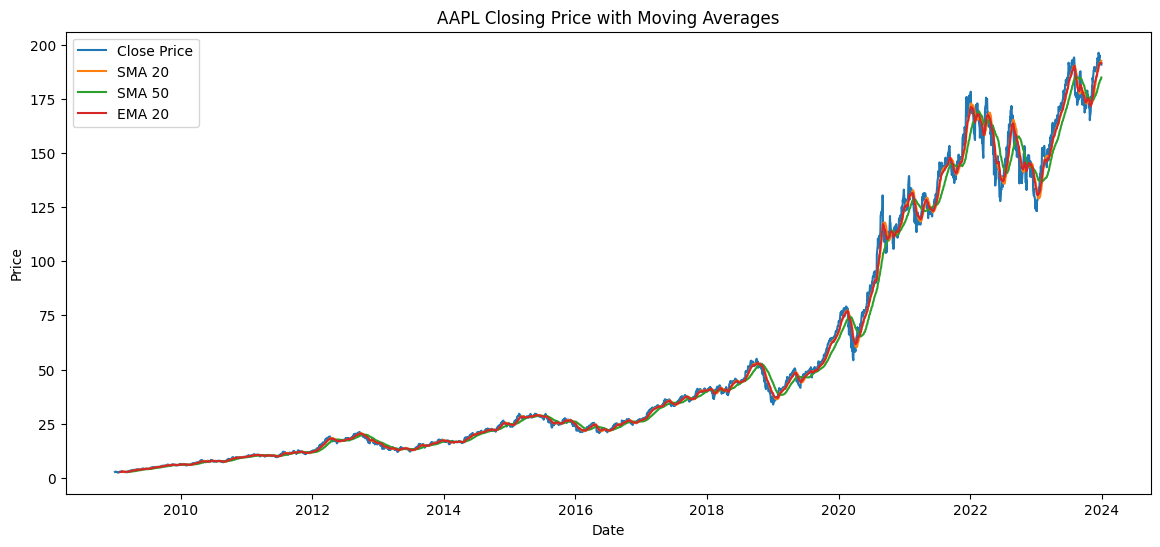

In [27]:
# Plot Price with Moving Averages

plt.figure(figsize=(14,6))

plt.plot(aapl["Date"], aapl["Close"], label="Close Price")

plt.plot(aapl["Date"], aapl["SMA_20"], label="SMA 20")

plt.plot(aapl["Date"], aapl["SMA_50"], label="SMA 50")

plt.plot(aapl["Date"], aapl["EMA_20"], label="EMA 20")

plt.title("AAPL Closing Price with Moving Averages")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.show()

# RSI Visualization

This chart visualizes RSI values over time.

The horizontal lines indicate:

- 70 → Overbought level
- 30 → Oversold level

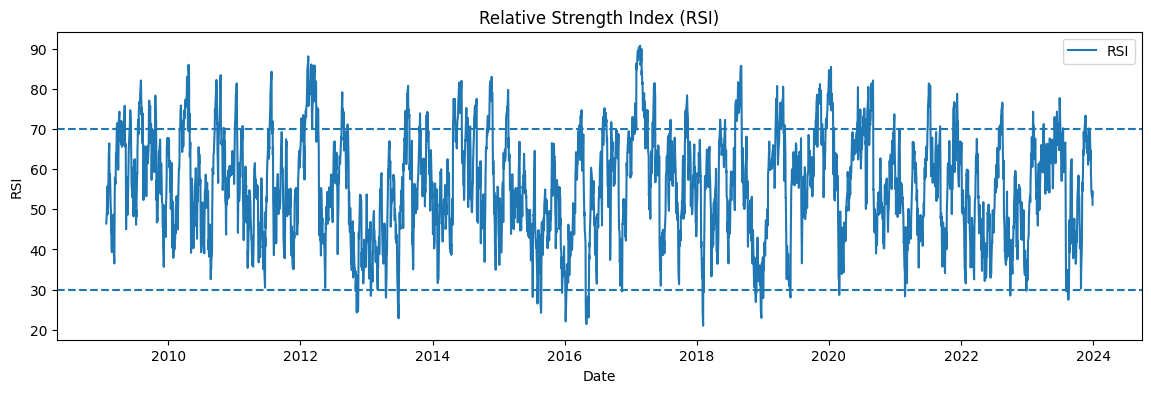

In [28]:
# Plot RSI

plt.figure(figsize=(14,4))

plt.plot(aapl["Date"], aapl["RSI"], label="RSI")

plt.axhline(70, linestyle="--")

plt.axhline(30, linestyle="--")

plt.title("Relative Strength Index (RSI)")

plt.xlabel("Date")

plt.ylabel("RSI")

plt.legend()

plt.show()

# MACD Visualization

This chart compares:

- MACD Line
- Signal Line

Crossovers between the lines may indicate changes in market momentum.

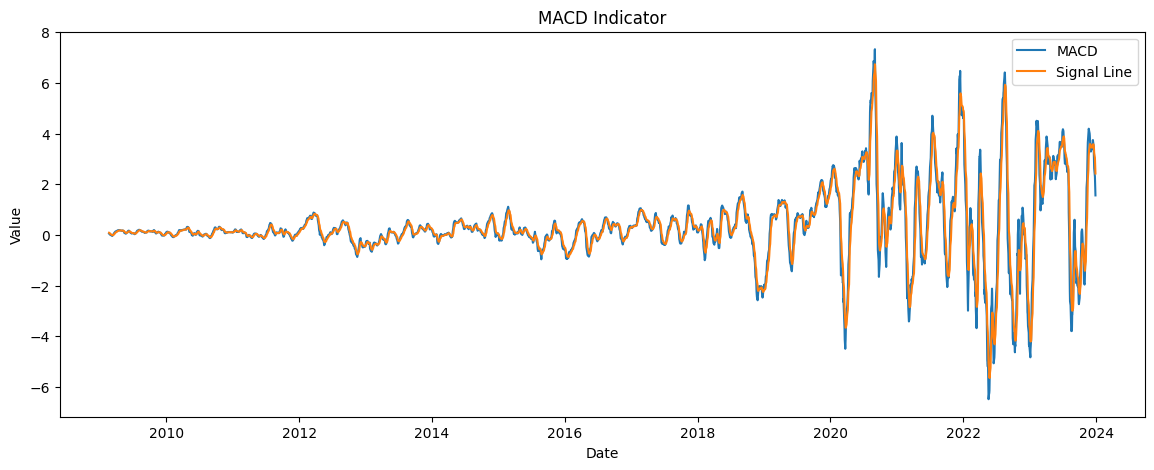

In [29]:
# Plot MACD

plt.figure(figsize=(14,5))

plt.plot(aapl["Date"], aapl["MACD"], label="MACD")

plt.plot(aapl["Date"], aapl["MACD_SIGNAL"], label="Signal Line")

plt.title("MACD Indicator")

plt.xlabel("Date")

plt.ylabel("Value")

plt.legend()

plt.show()

# Conclusion

The quantitative analysis of AAPL stock data revealed several important market trends and technical insights.

## Moving Average Analysis

The closing price showed a strong long-term upward trend, especially after 2019.  
The SMA 20, SMA 50, and EMA 20 closely followed the stock price movement and helped smooth short-term fluctuations.

Key observations:

- EMA 20 reacted faster to price changes compared to SMA indicators
- The stock experienced significant growth between 2020 and 2024
- Moving averages confirmed bullish momentum during major upward trends

## RSI Analysis

The RSI indicator fluctuated between the overbought and oversold thresholds throughout the period.

Important findings:

- Several RSI spikes above 70 indicated overbought conditions
- Multiple drops below 30 suggested oversold periods and possible recovery opportunities
- Most RSI values remained between 30 and 70, showing normal market momentum

## Overall Interpretation

The technical indicators demonstrated that AAPL experienced strong bullish growth with periodic corrections.

The combination of:

- Moving averages
- RSI
- MACD indicators

provided useful insights into:

- Trend direction
- Market momentum
- Potential reversal points
- Trading opportunities

These results show how quantitative analysis techniques can support data-driven financial decision-making.

In [30]:
aapl.head()

,Date,Close,High,Low,Open,Volume,Ticker,SMA_20,EMA_20,SMA_50,RSI,MACD,MACD_SIGNAL,MACD_HIST,Daily_Return,Cumulative_Return
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.042204,1.042204
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.016494,1.025014
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021609,1.002865
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.018570,1.021488
